<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deploy%20GCP/Deploy_de_apps_na_GCP_Treinamento_e_avalia%C3%A7%C3%A3o_do_algoritmo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importações

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical, set_random_seed
print(tf.__version__)

2.19.0


In [4]:
import sklearn
from sklearn.model_selection import train_test_split
print(sklearn.__version__)

1.6.1


In [5]:
import matplotlib
import matplotlib.pyplot as plt
print(matplotlib.__version__)

3.10.0


In [6]:
tf.config.experimental.enable_op_determinism()
set_random_seed(42)

# Carregamento e tratamento dos dados

In [7]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
X_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [9]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [10]:
X_train.min(), X_train.max()

(np.uint8(0), np.uint8(255))

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

In [14]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [16]:
class_names = ["airplane", "autmobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

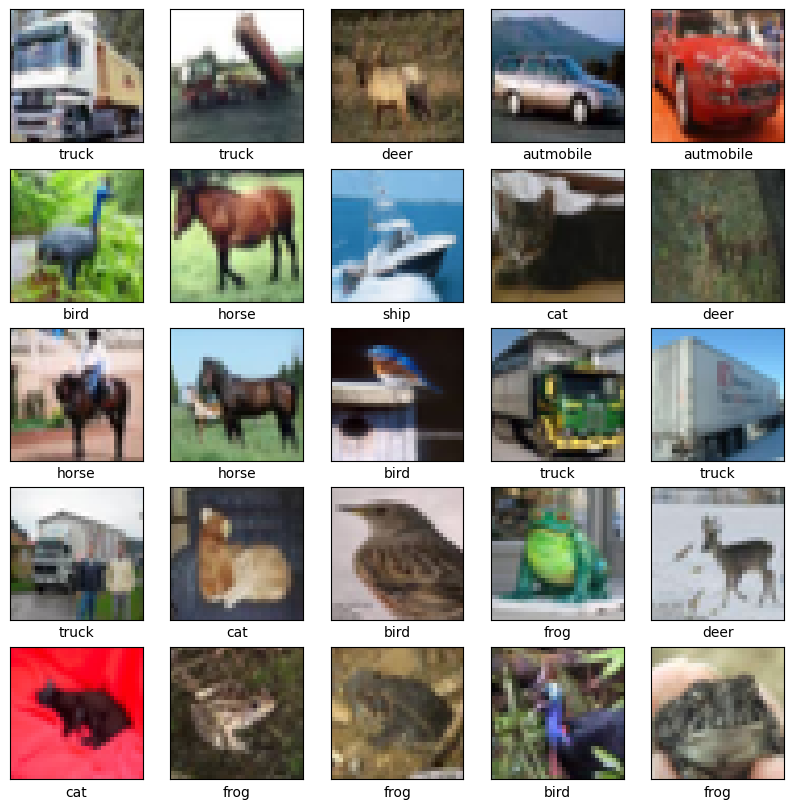

In [18]:
plt.figure(figsize = (10, 10))
for i in range(1, 26):
  plt.subplot(5, 5, i)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i])
  plt.xlabel(class_names[y_train[i].argmax()])
plt.show()

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

In [21]:
X_train.shape, X_val.shape, X_test.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3))

# Criação do modelo

In [23]:
model = Sequential([
   Input(shape = (32, 32, 3)),
   Conv2D(32, (3, 3), activation = "relu"),
   MaxPooling2D((2, 2)),
   Conv2D(32, (3, 3), activation = "relu"),
   MaxPooling2D((2, 2)),
   Flatten(),
   Dense(64, activation = "relu"),
   Dropout(0.5),
   Dense(10, activation = "softmax")
])


In [26]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

# Treinamento

In [27]:
history = model.fit(X_train, y_train, epochs = 20, validation_data = (X_val, y_val))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - accuracy: 0.2836 - loss: 1.9307 - val_accuracy: 0.4943 - val_loss: 1.4130
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.4509 - loss: 1.5152 - val_accuracy: 0.5601 - val_loss: 1.2477
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.5052 - loss: 1.3771 - val_accuracy: 0.5876 - val_loss: 1.1764
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.5428 - loss: 1.2893 - val_accuracy: 0.6175 - val_loss: 1.1028
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.5611 - loss: 1.2348 - val_accuracy: 0.6219 - val_loss: 1.0794
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.5791 - loss: 1.1815 - val_accuracy: 0.6235 - val_loss: 1.0764
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.5891 - loss: 1.1564 - val_accuracy: 0.6437 - val_loss: 1.0235
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.6090 -

In [28]:
model.save("cifar10_model.keras")

# Avaliação do modelo

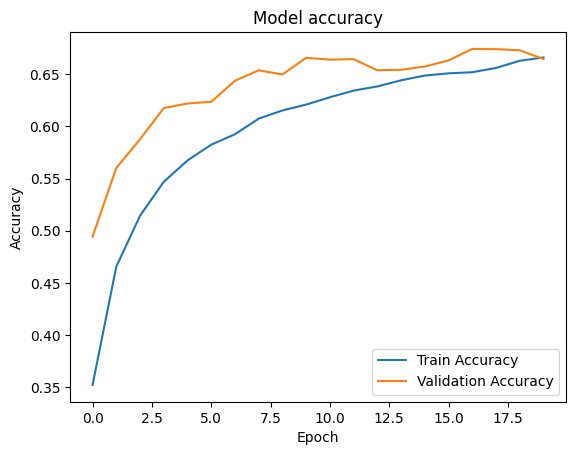

In [33]:
plt.plot(history.history["accuracy"], label = "Train Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [34]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6663 - loss: 0.9620


[0.9681211709976196, 0.6664000153541565]

In [35]:
predictions = model.predict(X_test[:10])
predicted_classes = predictions.argmax(axis = -1)
true_classes = y_test[:10].argmax(axis = -1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


In [36]:
predicted_classes

array([3, 8, 1, 8, 6, 6, 1, 6, 3, 1])

In [37]:
true_classes

array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1])

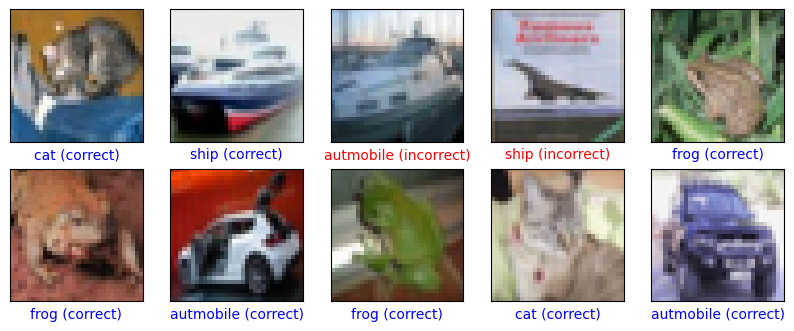

In [38]:
plt.figure(figsize = (10, 10))
for i in range(1, 11):
  plt.subplot(5, 5, i)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_test[i - 1])
  color = "blue" if predicted_classes[i - 1] == true_classes[i - 1] else "red"
  plt.xlabel(f"{class_names[predicted_classes[i - 1]]} ({"correct" if color == "blue" else 'incorrect'})", color = color)
plt.show()